In [1]:
#Librerías

import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Constantes físicas

h = 6.62607015e-34 #Constante de Planck (J·s)
c = 2.99792458e8 #Velocidad de la luz (m/s)
k_B = 1.380649e-23 #Constante de Boltzmann (J/K)

In [3]:
#Funciones

def blackbody(lambda_data, T):
    return ((2*h*c**2)/(lambda_data**5)) / (np.exp((h*c)/(lambda_data*k_B*T))-1)

def add_absorption(lambda_data, B_data, lambda_absor, depth, gamma):
    lorentzian_profile = depth*gamma**2 / ((lambda_data - lambda_absor)**2 + gamma**2)
    return B_data * (1 - lorentzian_profile)

def redshift(lambda_data, z):
    return lambda_data*(1+z)

def noise(signal):
    noise = np.random.normal(0,10**12,len(signal))
    return signal + noise

In [4]:
#Parámetros

T = 6000 #Temperatura
z = 0.5 #Redshift

#Parámetros de la línea Hα
lambda_Halpha = 656.28e-9  #656.28 nm en metros
depth = 0.5 #Profundidad de absorción (entre 0 y 1)
gamma = 1e-9 #ancho Lorentziano

In [5]:
#Dominio de Longitud de Onda (en nm)

lambda_0 = 100
lambda_f = 3000
N_lambda = 2500

lambda_data = np.linspace(lambda_0, lambda_f, N_lambda) * 1e-9 #lo paso a metros

Generación de curva de cuerpo negro

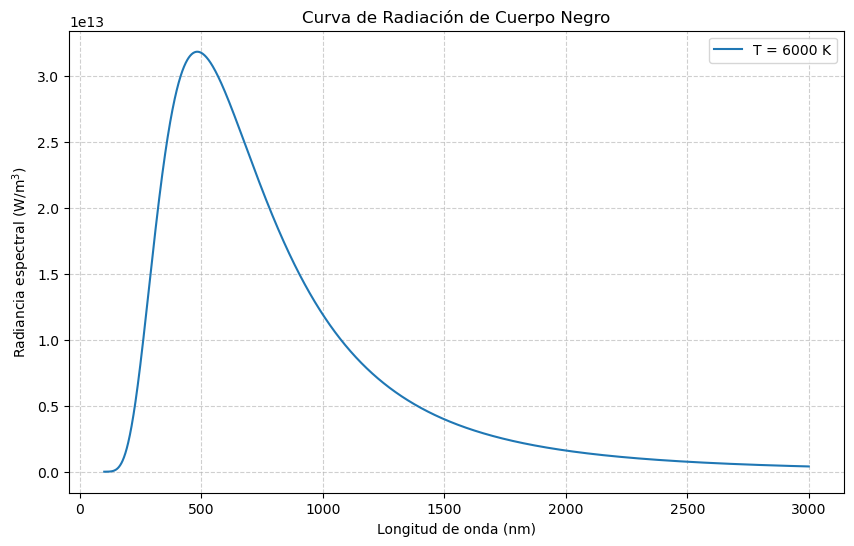

In [7]:
#Datos de radiación
B_data = blackbody(lambda_data, T)

#Graficar
plt.figure(figsize=(10, 6))
plt.plot(lambda_data * 1e9, B_data, label=f'T = {T} K')
plt.title('Curva de Radiación de Cuerpo Negro')
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Radiancia espectral (W/m$^3$)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Linea de Balmer del Hidrógeno

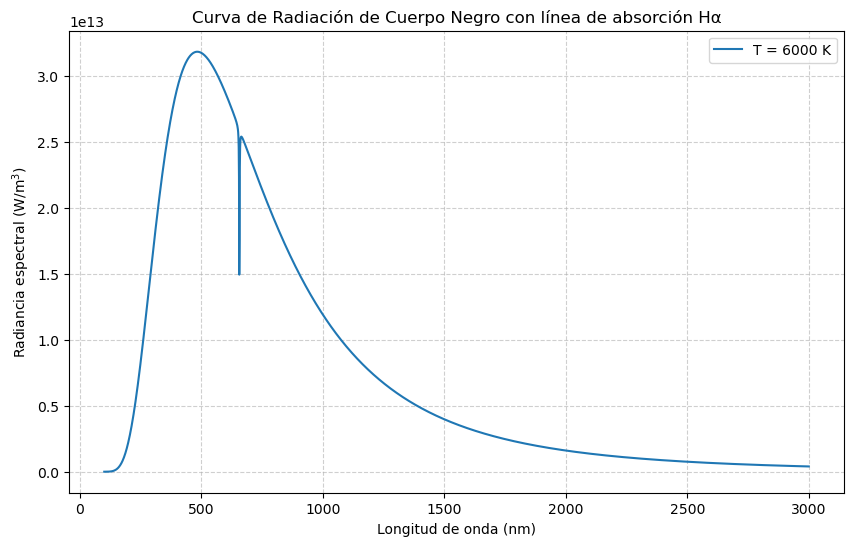

In [9]:
#Datos de radiación
B_abs_data = add_absorption(lambda_data, B_data, lambda_Halpha, depth, gamma=gamma)

#Graficar
plt.figure(figsize=(10, 6))
plt.plot(lambda_data * 1e9, B_abs_data, label=f'T = {T} K')
plt.title('Curva de Radiación de Cuerpo Negro con línea de absorción Hα')
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Radiancia espectral (W/m$^3$)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
# plt.xlim(600,750)
plt.show()

Agregar redshift

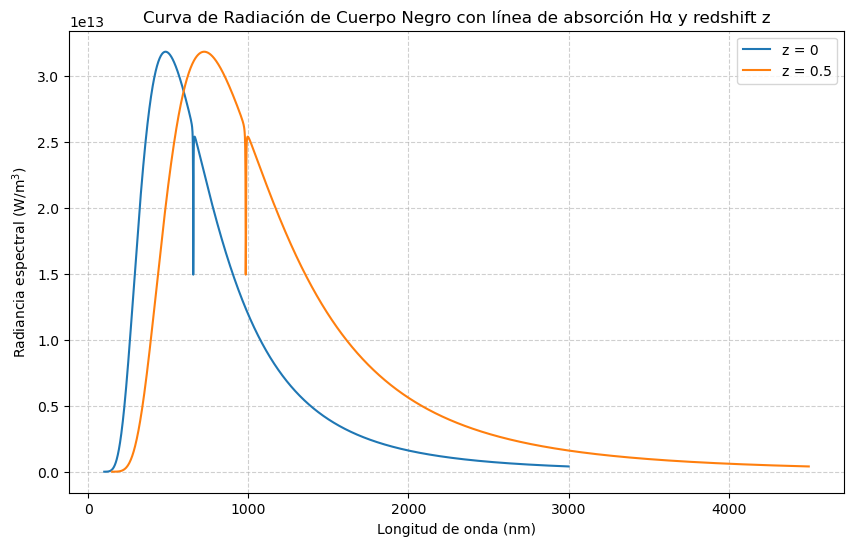

In [11]:
#Datos de longitud de onda corridos
lambda_shift_data = redshift(lambda_data, z)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(lambda_data * 1e9, B_abs_data, label=f'z = 0')
plt.plot(lambda_shift_data * 1e9, B_abs_data, label=f'z = {z}')
plt.title('Curva de Radiación de Cuerpo Negro con línea de absorción Hα y redshift z')
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Radiancia espectral (W/m$^3$)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
# plt.xlim(400, 1000)
plt.show()

Agregar ruido

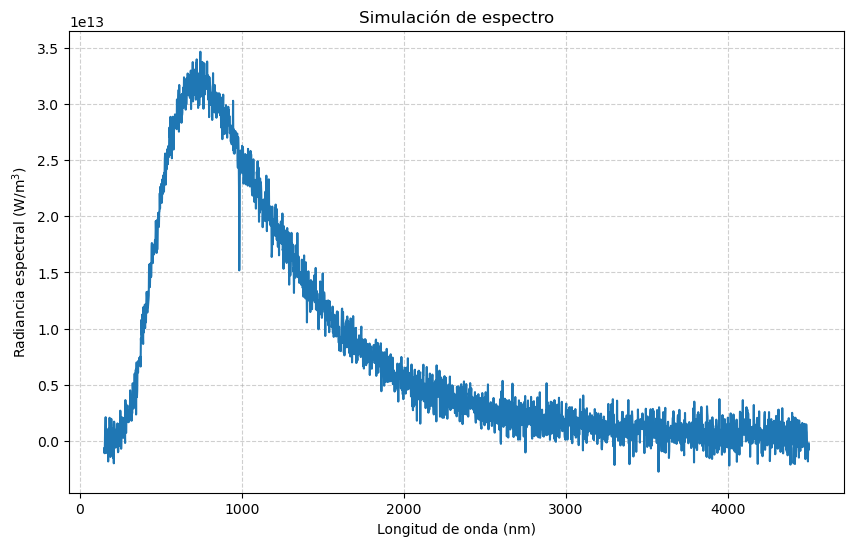

In [13]:
#Datos de radiación
B_abs_noise_data = noise(B_abs_data)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(lambda_shift_data * 1e9, B_abs_noise_data)
plt.title('Simulación de espectro')
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Radiancia espectral (W/m$^3$)')
plt.grid(True, linestyle='--', alpha=0.6)
# plt.xlim(400, 1000)
plt.show()